# Projicering af koordinater for kliniske forsøgssteder til kortlægning med PROC GPROJECT

## Resumé

Et klinisk driftsteam skal afbilde det geografiske fodaftryk af et fase III-forsøg med flere forsøgssteder på et fladt kort. Denne notebook genererer syntetiske bredde-/længdegradskoordinater for forsøgssteder samlet omkring fem amerikanske regionale knudepunkter og bruger derefter **PROC GPROJECT** til at konvertere de sfæriske koordinater til kartesiske X/Y-værdier med tre projektionsmetoder (Albers arealtro konisk, Lambert konform med brugerdefinerede standardparalleller og regional beskæring, samt gnomonisk centreret på det kontinentale USA), hvilket illustrerer, hvordan valg af projektion og beskæring påvirker et kort over forsøgssteder.

## Datakilder

| Datasæt | Rækker | Nøglevariable | Beskrivelse |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 knudepunkter x 12 forsøgssteder) | `site_id` ($8 ID), `region` ($12), `x` (længdegrad, grader, øst-positiv), `y` (breddegrad, grader), `enroll` (inkluderede forsøgspersoner), `segment` (kortsegment-id) | Syntetiske fase III-forsøgsstedslokationer spredt omkring fem amerikanske regionale knudepunkter (Vest, Midtvesten, Nordøst, Syd, Sydøst) ved brug af `rand('normal')`-jitter og `rand('poisson')`-inklusionsantal |

# Projicering af koordinater for kliniske forsøgssteder med PROC GPROJECT

Når en sponsor kører et geografisk spredt fase III-forsøg, ønsker den kliniske driftsgruppe ofte ét samlet kort, der viser hvert eneste forsøgssted, størrelses- eller farvekodet efter inklusion. Forsøgsstedernes placeringer kommer som **længdegrad-/breddegradspar**, men et fladt kort kræver **planare X/Y-koordinater**. `PROC GPROJECT` udfører denne sfærisk-til-kartesiske konvertering ved at anvende en kartografisk projektion, så afstande og arealer gengives fornuftigt.

I denne notebook vil vi:

1. Generere syntetiske koordinater for forsøgssteder samlet omkring fem amerikanske regionale knudepunkter.
2. Anvende standardprojektionen **Albers arealtro**.
3. Anvende en **Lambert konform**-projektion med brugerdefinerede standardparalleller og beskæring til det sammenhængende USA.
4. Anvende en **gnomonisk** projektion centreret på landets geografiske midte, hvor de oprindelige koordinater bevares med `ASIS`.

Alt er selvstændigt: ingen eksterne filer, intet netværk.

## Trin 1 — Generer syntetiske koordinater for forsøgssteder

Vi seeder RNG'en med `call streaminit` for reproducerbarhed og placerer derefter 12 forsøgssteder omkring hver af fem regionale knudepunkter. Længdegrader gemmes øst-positive i grader (negative for den vestlige halvkugle) og breddegrader i grader. Hver række bærer også et inklusionsantal og en `segment`-variabel (GPROJECT bevarer ikke-koordinatkolonner gennem projektionen).

In [1]:
data trial_sites;
    CALL streaminit(20260531);
    LÆNGDE site_id $8 region $12;
    /* Fem amerikanske regionale knudepunkter: længdegrad (øst+), breddegrad */
    TABEL clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    TABEL clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    GØR hub = 1 TIL 5;
        /* Regionsnavn tildelt direkte (IF/ELSE) i stedet for et _temporary_
           char-array-opslag - et array med diakritiske tegn (fx 'Nordøst')
           afkortes uforudsigeligt af motoren uanset den erklærede LÆNGDE. */
        HVIS hub = 1 SÅ region = 'Vest';
        ELLERS HVIS hub = 2 SÅ region = 'Midtvesten';
        ELLERS HVIS hub = 3 SÅ region = 'Nordøst';
        ELLERS HVIS hub = 4 SÅ region = 'Syd';
        ELLERS region = 'Sydøst';
        GØR s = 1 TIL 12;
            site_id = cats('S', SKRIV_V(hub, z1.), SKRIV_V(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* længdegrad, grader */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* breddegrad, grader */
            enroll  = round(rand('poisson', 60));           /* inkluderede forsøgspersoner */
            segment = 1;
            UDDATA;
        SLUT;
    SLUT;
    FJERN hub s;
KØR;

PROCEDURE UDSKRIV data=trial_sites(obs=10) MÆRKAT;
    MÆRKAT site_id="Forsøgssted-ID" region="Region" x="Længdegrad" y="Breddegrad"
          enroll="Inkluderede" segment="Segment";
    TITEL "Stikprøve af syntetiske kliniske forsøgssteder (uprojiceret lon/lat)";
KØR;


                          Stikprøve af syntetiske kliniske forsøgssteder (uprojiceret lon/lat)                          

  Obs   Forsøgssted-ID  Region       Længdegrad     Breddegrad  Inkluderede  Segment
    1  S101             Vest    -121.6437232216  37.7677668495           65        1
    2  S102             Vest    -120.7384024716  37.5083287903           61        1
    3  S103             Vest    -121.5133780284  37.8633933883           72        1
    4  S104             Vest    -121.2086817368  38.7723343392           68        1
    5  S105             Vest    -121.0499572297   37.175813806           54        1
    6  S106             Vest    -124.0531899967   35.778231667           72        1
    7  S107             Vest    -120.9370181032  39.0576714397           64        1
    8  S108             Vest    -126.8495029747  36.6474680375           55        1
    9  S109             Vest     -123.475989897  37.1427965254           56        1
   10  S110             Vest


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Trin 2 — Standardprojektion: Albers arealtro

Den **Albers** arealtro koniske projektion er GPROJECT's standard og et fornuftigt valg til et landsdækkende kort, hvor det er vigtigt at bevare *relativt areal* (f.eks. ved sammenligning af regionale optageområders størrelse).

Fordi vores koordinater er gemt i **grader** med **øst-positiv længdegrad**, angiver vi valgmulighederne `DEGREE` og `EASTLONG`. `ID`-udsagnet navngiver den variabel, der entydigt identificerer hver enhed; de projicerede planare koordinater skrives tilbage i `x` og `y` i `OUT=`-datasættet.

In [2]:
PROCEDURE GPROJECT data=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
KØR;

PROCEDURE UDSKRIV data=sites_albers(obs=10) MÆRKAT;
    MÆRKAT site_id="Forsøgssted-ID" region="Region" x="X (planar)" y="Y (planar)"
          enroll="Inkluderede" segment="Segment";
    TITEL "Forsøgssteder efter Albers arealtro-projektion (planar X/Y)";
KØR;


                          Stikprøve af syntetiske kliniske forsøgssteder (uprojiceret lon/lat)                          

                              Forsøgssteder efter Albers arealtro-projektion (planar X/Y)                               

  Obs   Forsøgssted-ID  Region     X (planar)    Y (planar)  Inkluderede  Segment
    1  S101             Vest     -0.346124731  0.0516986079           65        1
    2  S102             Vest    -0.3353644139  0.0440400181           61        1
    3  S103             Vest    -0.3439609675  0.0528501365           72        1
    4  S104             Vest    -0.3357513354   0.067213083           68        1
    5  S105             Vest    -0.3410170723  0.0394882801           54        1
    6  S106             Vest    -0.3879364507  0.0273340733           72        1
    7  S107             Vest    -0.3309127579  0.0711146305           64        1
    8  S108             Vest    -0.4204191205  0.0538118922           55        1
    9  S109       


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Trin 3 — Lambert konform-projektion med brugerdefinerede paralleller og beskæring

Den **Lambert konform**-koniske projektion bevarer *form og lokale vinkler*, hvilket er at foretrække, når kortet bruges til navigation eller til at lægge retningsbestemte elementer oven på. For det sammenhængende USA er standardparalleller nær 33 grader N og 45 grader N konventionelle, så vi sætter dem eksplicit med `PARALLEL1=` og `PARALLEL2=`.

Vi begrænser også kortet til det sammenhængende USA-vindue ved hjælp af beskæringsvalgmulighederne `LATMIN=`, `LATMAX=`, `LONGMIN=` og `LONGMAX=`. Ethvert forsøgssted, der falder uden for denne breddegrad-/længdegradsboks, frasorteres før projektionen, så antallet af observationer i output kan være lavere end i input.

In [3]:
PROCEDURE GPROJECT data=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
KØR;

PROCEDURE UDSKRIV data=sites_lambert(obs=10) MÆRKAT;
    MÆRKAT site_id="Forsøgssted-ID" region="Region" x="X (planar)" y="Y (planar)"
          enroll="Inkluderede" segment="Segment";
    TITEL "Forsøgssteder efter Lambert konform-projektion (beskåret til det sammenhængende USA)";
KØR;


                              Forsøgssteder efter Albers arealtro-projektion (planar X/Y)                               

                  Forsøgssteder efter Lambert konform-projektion (beskåret til det sammenhængende USA)                  

  Obs   Forsøgssted-ID  Region     X (planar)    Y (planar)  Inkluderede  Segment
    1  S101             Vest    -0.3473024124  0.0279382533           65        1
    2  S102             Vest    -0.3365626234  0.0201991247           61        1
    3  S103             Vest    -0.3451238364  0.0290365995           72        1
    4  S104             Vest    -0.3367881094  0.0430616123           68        1
    5  S105             Vest    -0.3422656751  0.0158037156           54        1
    6  S106             Vest    -0.3894389642  0.0046370991           72        1
    7  S107             Vest    -0.3319086764  0.0468276119           64        1
    8  S109             Vest    -0.3746144745  0.0248234546           56        1
    9  S110       


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Trin 4 — Gnomonisk projektion centreret på landet, med bevarelse af originalerne

Den **gnomoniske** asimutale projektion gengiver enhver storcirkel som en lige linje, hvilket er nyttigt, når man vil ræsonnere om den korteste vej mellem forsøgssteder (for eksempel ved planlægning af en monitors besøgsrute). Forvrængningen øges med afstanden fra projektionspolen, så vi centrerer polen på det kontinentale USA's geografiske midte med `POLELAT=39` og `POLELONG=-98`.

Valgmuligheden `ASIS` fortæller GPROJECT, at de oprindelige, uprojicerede koordinater skal bevares sammen med de projicerede værdier, så outputdatasættet bærer både den planare `X`/`Y` og kilde-`LONG`/`LAT` — praktisk til at koble inklusionsmetrikker tilbage til begge koordinatrum.

`PARMENTRY`-udsagnet vises som en alternativ måde at angive projektionsparametre som nøgle=værdi-overstyringer på.

In [4]:
PROCEDURE GPROJECT data=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
KØR;

PROCEDURE UDSKRIV data=sites_gnomon(obs=10) MÆRKAT;
    MÆRKAT site_id="Forsøgssted-ID" region="Region" x="X (planar)" y="Y (planar)"
          long="Længdegrad (original)" lat="Breddegrad (original)"
          enroll="Inkluderede" segment="Segment";
    TITEL "Forsøgssteder efter gnomonisk projektion (ASIS bevarer original LONG/LAT)";
KØR;


                  Forsøgssteder efter Lambert konform-projektion (beskåret til det sammenhængende USA)                  

                       Forsøgssteder efter gnomonisk projektion (ASIS bevarer original LONG/LAT)                        

  Obs   Forsøgssted-ID  Region     X (planar)     Y (planar)  Inkluderede  Segment   Længdegrad (original)  Breddegrad (original)
    1  S101             Vest    -0.3343477981   0.0213614461           65        1         -121.6437232216          37.7677668495
    2  S102             Vest    -0.3221611694   0.0134152735           61        1         -120.7384024716          37.5083287903
    3  S103             Vest    -0.3319480803   0.0225717184           72        1         -121.5133780284          37.8633933883
    4  S104             Vest    -0.3230855797   0.0375741352           68        1         -121.2086817368          38.7723343392
    5  S105             Vest    -0.3283677206   0.0086308769           54        1         -121.0499572297


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Trin 5 — Vis det projicerede forsøgsstedskort

Hele pointen med at projicere er at kunne tegne kortet. Vi fører Albers `OUT=`-datasættet direkte ind i **PROC SGPLOT**, hvor vi plotter det planare `X`/`Y` og farvekoder hvert markørpunkt efter `region`. Fordi projektionen bevarede den relative geografi, lander de fem knudepunktsklynger i deres forventede hjørner af plottet — Vest til venstre, Nordøst øverst til højre, Syd og Sydøst langs bunden — hvilket giver den kliniske driftsgruppe det arealtro fodaftryk, der er beskrevet i resuméet.

                       Forsøgssteder efter gnomonisk projektion (ASIS bevarer original LONG/LAT)                        




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


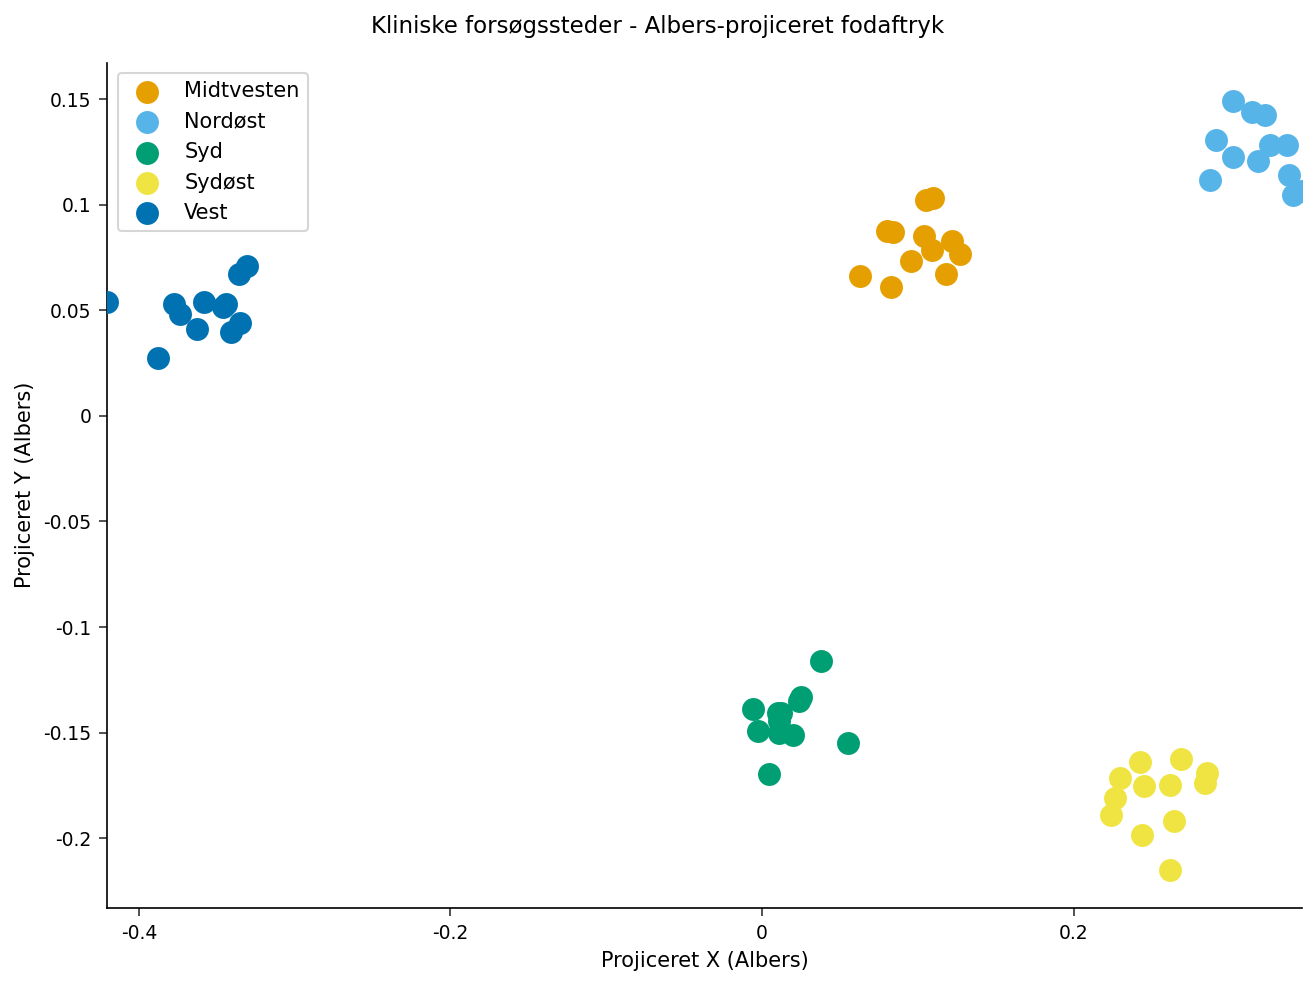

In [5]:
PROCEDURE SGPLOT data=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS label="Projiceret X (Albers)";
    YAXIS label="Projiceret Y (Albers)";
    TITEL "Kliniske forsøgssteder - Albers-projiceret fodaftryk";
KØR;


## Fortolkning af resultaterne

- **Albers (trin 2)** transformerede alle 60 forsøgssteder til planare koordinater, mens det relative areal blev bevaret — klyngerne Vest, Midtvesten, Nordøst, Syd og Sydøst beholder deres proportionale rumlige fodaftryk, hvilket er det rigtige grundlag for et arealtro inklusions-varmekort.
- **Lambert med beskæring (trin 3)** bevarede lokal form og frasorterede, ved at anvende vinduet `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`, de syntetiske forsøgssteder, der lå spredt uden for det sammenhængende USA — her faldt antallet fra 60 til 58, så de to koordinater uden for gitteret, som ellers ville strække kortet, blev fjernet før projektionen.
- **Gnomonisk med `ASIS` (trin 4)** centrerede projektionen på landets indre og producerede, takket være `ASIS`, et datasæt, der bærer både de projicerede `X`/`Y` og de oprindelige `LONG`/`LAT`. Storcirkler fremstår som lige linjer, så lige-linje-afstande på dette kort tilnærmer de reelle korteste veje mellem forsøgssteder.
- **Det viste fodaftryk (trin 5)** bekræfter, at projektionen virkede: at plotte Albers `X`/`Y` efter region placerer de fem knudepunktsklynger i deres forventede hjørner af planet — det arealtro forsøgsstedskort, resuméet lovede.

**Konklusion for klinisk drift:** projektionen er ikke kosmetisk. Vælg **Albers** til arealtro inklusionstæthed, **Lambert** til formtro overlejringer med regional beskæring, og **gnomonisk**, når afstanden mellem forsøgssteder driver analysen. Som trin 5 viser, kan det projicerede `OUT=`-datasæt føres direkte ind i PROC SGPLOT (eller PROC GMAP) for at tegne det endelige forsøgsstedskort.